In [68]:
import os
os.environ["OMP_NUM_THREADS"] = "3"

In [82]:
import pandas as pd
from pybaseball import statcast_pitcher
from pybaseball import pitching_stats
from pybaseball import playerid_lookup
from pybaseball import playerid_reverse_lookup
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, log_loss

In [67]:
# Pulls list of qualified pitchers and preprocesses the following:
# - A list of datasets for each pitching season, prepared for Random Forest pitch prediction modeling
# - A dataset of pitch mix qualities for each pitching season, prepared for clustering
#id_list, profiles_df = qualifiedPitchers()
#p_dfs = buildDatasets(id_list)

In [60]:
# builds list of lists including pitcher seasons and f1 scores
#p_f1s = []
#for p in p_dfs:
#    f1 = f1FromRF(p[2])
#    p_f1s.append([p[0], p[1], f1])
#    print("RF model built")

In [162]:
columns = ["IDfg", "Season", "f1", "baseline_f1", "f1_diff"]
metrics_df = pd.DataFrame(metrics, columns=columns)
lookup_df = playerid_reverse_lookup(metrics_df["IDfg"].values, key_type='mlbam')
id_map = dict(zip(lookup_df["key_mlbam"], lookup_df["key_fangraphs"]))
metrics_df["IDfg"] = metrics_df["IDfg"].map(id_map)

dfs = []
for year in range(2015, 2025):
    df = pitching_stats(year)
    df = df[['IDfg', 'Season', 'SO', 'FIP', 'HardHit%']]
    dfs.append(df)
    

success = pd.concat(dfs, ignore_index=True)
    
mets_suc = pd.merge(metrics_df, success, on=["IDfg", "Season"], how="left")

In [163]:
clusters = profiles_df[['IDfg', 'Season', 'cluster']]
mets_suc = pd.merge(mets_suc, clusters, on=["IDfg", "Season"], how="left")
cluster1 = mets_suc[mets_suc['cluster'] == 1]

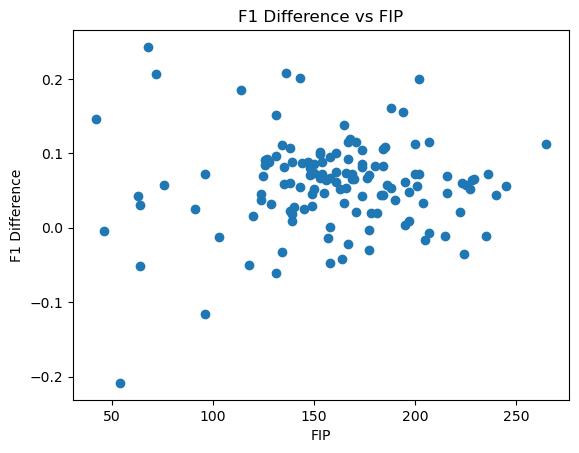

In [166]:
plt.scatter(cluster1['SO'], cluster1['f1_diff'])
plt.xlabel('FIP')
plt.ylabel('F1 Difference')
plt.title('F1 Difference vs FIP')
plt.show()

In [161]:
mets_suc

,IDfg,Season,f1,baseline_f1,f1_diff,SO,FIP,HardHit%,cluster
0,4505,2015,0.238652,0.191585,0.047067,164,3.75,0.329,0
1,3184,2015,0.254029,0.196717,0.057312,225,2.78,0.308,1
2,6893,2015,0.195779,0.189735,0.006044,176,3.53,0.318,3
3,7872,2015,0.226737,0.206690,0.020047,212,2.98,0.329,2
4,2036,2015,0.286868,0.247940,0.038928,301,1.99,0.245,0
...,...,...,...,...,...,...,...,...,...
550,15890,2024,0.212923,0.124513,0.088409,161,4.21,0.353,2
551,15873,2024,0.177243,0.108697,0.068546,184,3.83,0.378,2
552,17479,2024,0.266205,0.179185,0.087021,194,3.48,0.349,0
553,25377,2024,0.200074,0.148918,0.051156,170,3.93,0.417,2


In [ ]:
metrics = []
for p in p_dfs:
        f1 = f1FromRF(p[2])
        f1bs = pitcher_baseline_distribution(p[2])
        metrics.append([p[0], p[1], f1, f1bs, f1-f1bs])
        print("RF model built")

In [115]:
metrics

[[519455,
  2015,
  0.23865175628270632,
  0.19158456743173308,
  0.047067188850973246],
 [456034,
  2015,
  0.25402948173731177,
  0.19671737836631453,
  0.057312103370997236],
 [456501, 2015, 0.1957794732567489, 0.18973520758417783, 0.006044265672571075],
 [475115, 2015, 0.2267369136934354, 0.20669008587041376, 0.02004682782302164],
 [477132, 2015, 0.2868682684341342, 0.24794025157232708, 0.038928016861807135],
 [452657,
  2015,
  0.20223914657513214,
  0.20876395534290268,
  -0.006524808767770535],
 [523989, 2015, 0.26499299719887953, 0.18574910691080937, 0.07924389028807016],
 [460059, 2015, 0.26575507825507827, 0.304837796842346, -0.03908271858726775],
 [112526, 2015, 0.30807535646245326, 0.23802795326332696, 0.0700474031991263],
 [471911,
  2015,
  0.24988752513904214,
  0.22826786872768076,
  0.021619656411361377],
 [501957, 2015, 0.2147548566142461, 0.199, 0.015754856614246082],
 [543101, 2015, 0.24882507252819241, 0.1589936071752302, 0.08983146535296221],
 [572971, 2015, 0.241

In [104]:
def pitcher_baseline_distribution(df):
    target = "pitch_type"
    
    y = df[target]

    # Encode labels
    le = LabelEncoder()
    y = le.fit_transform(y)

    # Train/test split (same as your model)
    split_index = int(len(y) * (1/3))
    y_test  = y[:split_index]
    y_train = y[split_index:]

    # Get distribution from training data
    counts = np.bincount(y_train)
    probs = counts / counts.sum()

    # Sample predictions from distribution
    y_pred = np.random.choice(len(probs), size=len(y_test), p=probs)

    # Compute F1
    f1 = f1_score(y_test, y_pred, average='macro')

    return f1

In [108]:
# takes a dataset, builds random forest model, and computes f1 score
def rolling_evaluation(df, feature_cols, target_col="pitch_type", initial_train_size=0.6, step_size=0.1):
    
    # Sort chronologically if you have an ordering column
    # Example: df = df.sort_values(by=["game_date", "pitch_number"])
    
    X = df[feature_cols].copy()
    y = df[target_col].copy()

    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    n = len(df)
    train_end = int(n * initial_train_size)
    step = int(n * step_size)

    f1_scores = []
    log_losses = []

    while train_end + step <= n:
        X_train = X.iloc[:train_end]
        y_train = y_encoded[:train_end]

        X_test = X.iloc[train_end:train_end + step]
        y_test = y_encoded[train_end:train_end + step]

        # Train model
        model = RandomForestClassifier(random_state=42)
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        # Metrics
        f1 = f1_score(y_test, y_pred, average='macro')
        ll = log_loss(y_test, y_prob, labels=np.arange(len(le.classes_)))

        f1_scores.append(f1)
        log_losses.append(ll)

        # Expand training window (rolling forward)
        train_end += step

    return {
        "avg_f1": np.mean(f1_scores),
        "avg_log_loss": np.mean(log_losses),
        "f1_scores": f1_scores,
        "log_losses": log_losses
    }

In [25]:
# loading saved RF dataframes
with open("mlb_data.pkl", "rb") as f:
    p_dfs = pickle.load(f)

In [24]:
# saving loaded RF dataframes
with open("mlb_data.pkl", "wb") as f:
    pickle.dump(p_dfs, f)

In [59]:
# loading saved profile dataframes
with open("p_profiles.pkl", "rb") as f:
    profiles_df = pickle.load(f)

In [58]:
# saving loaded profile dataframes
with open("p_profiles.pkl", "wb") as f:
    pickle.dump(profiles_df, f)

In [6]:
# loading saved f1 scores
with open("f1_scores.pkl", "rb") as f:
    p_f1s = pickle.load(f)

In [31]:
# saving loaded f1 scores
with open("f1_scores.pkl", "wb") as f:
    pickle.dump(p_f1s, f)

In [70]:
# This code block clusters pitchers by k-means.  I would like to improve the quality of my clustering later with hyperparameter tuning
# scale and cluster data
c_data = profiles_df.drop(columns=['IDfg', 'Season'])
scaler = StandardScaler()
c_data_scaled = scaler.fit_transform(c_data)
kmeans = KMeans(n_clusters=5, random_state=100, n_init=10)
kmeans.fit(c_data_scaled)
# this adds the cluster labels to the profile dataset
profiles_df['cluster'] = kmeans.labels_

C:\Users\brian\Documents\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


C:\Users\brian\Documents\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\brian\Documents\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\brian\Documents\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\brian\Documents\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is k

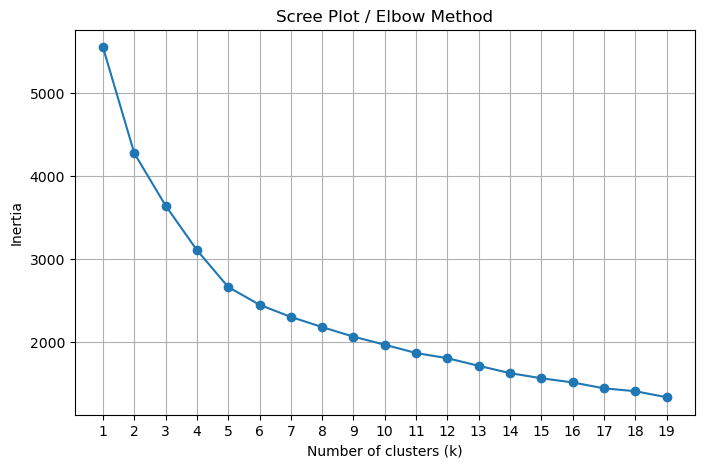

In [69]:
# building scree plot to determine optimal number of clusters
cluster_range = range(1, 20)
inertia_values = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=100, n_init=10)
    kmeans.fit(c_data_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(cluster_range, inertia_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Scree Plot / Elbow Method')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [3]:
# creates dataframe of pitching profiles, including IDs
yearly_dfs = []
for year in range(2015, 2026):
    leaderboard = pitching_stats(year)  
    yearly_df = leaderboard[['IDfg', 'Season', 'FB% 2', 'FBv', 'SL%', 'SLv', 'CT%', 'CTv', 'CB%', 'CBv', 'CH%', 'CHv']]
    yearly_df = yearly_df.fillna(0)
    yearly_dfs.append(yearly_df)
profile_dfs = pd.concat(yearly_dfs, ignore_index=True)

In [37]:
# pulls array containing pitcher IDs and season # for qualified pitchers (162 innings thrown)
def qualifiedPitchers():
    id_list = []
    yearly_dfs = []
    for year in range(2015, 2025):
        qual_pitcher = pitching_stats(year)
        id_list_ind = qual_pitcher.iloc[:, 0].values.tolist()
        mlbam_ids = fgToMlbam(id_list_ind)
        for i in mlbam_ids:
            id_list.append([i, year])
        
        yearly_df = qual_pitcher[['IDfg', 'Season', 'FB% 2', 'FBv', 'SL%', 'SLv', 'CT%', 'CTv', 'CB%', 'CBv', 'CH%', 'CHv']]
        yearly_df = yearly_df.fillna(0)
        yearly_dfs.append(yearly_df)
    prof_dfs = pd.concat(yearly_dfs, ignore_index=True)
    return id_list, prof_dfs

In [15]:
# converts Fangraph IDs to MLBAM IDs
def fgToMlbam(id_list):
    all_p_ids = playerid_reverse_lookup(id_list, key_type='fangraphs')
    mlbam_ids = all_p_ids['key_mlbam'].values
    return mlbam_ids

In [131]:
# converts MLBAM IDs to Fangraph IDs
def mlbamToFg(id_list):
    all_p_ids = playerid_reverse_lookup(id_list, key_type='mlbam')
    fg_ids = all_p_ids['key_fangraphs'].values
    return fg_ids

In [18]:
# preparing dataset to include all random forests
def prepareForRF(dataset):
    dataset = dataset[dataset["game_type"] == "R"].copy()
    dataset = dataset[['pitch_type', 'balls', 'strikes', 'stand', 'inning', 'outs_when_up', 'on_1b', 'on_2b', 'on_3b']].copy()
    dataset["lag_pitch"] = dataset["pitch_type"].shift(-1)
    dataset["lag_pitch2"] = dataset["pitch_type"].shift(-2)
    dataset["br1"] = dataset["on_1b"].notna().astype(int)
    dataset["br2"] = dataset["on_2b"].notna().astype(int)
    dataset["br3"] = dataset["on_3b"].notna().astype(int)
    dataset = dataset.drop(columns=["on_1b", "on_2b", "on_3b"])
    datasetRF = dataset[(dataset["strikes"] == 2) | ((dataset["strikes"] == 1) & (dataset["balls"] == 3))].copy()
    return datasetRF

In [14]:
# Creates nested array carrying ID and correlated prepared dataset
def buildDatasets(id_list): 
    pitcher_dfs = []
    for p_season in id_list:
        pitcher_df = statcast_pitcher(f'{p_season[1]}-03-10', f'{p_season[1]}-08-10', p_season[0])
        print(p_season[0])
        print(p_season[1])
        pitcher_df = prepareForRF(pitcher_df)
        pitcher_dfs.append([p_season[0], p_season[1], pitcher_df])
    return pitcher_dfs